In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Darts
from darts import TimeSeries, metrics
from darts.models import SKLearnClassifierModel, XGBClassifierModel
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import MinMaxScaler

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix as sk_confusion_matrix,
    roc_auc_score, roc_curve
)

# SHAP
import shap

COLORS = {
    'IHSG': '#2E7D32', 'IHSG_light': '#4CAF50',
    'M2_YoY': '#1976D2', 'USDIDR': '#7B1FA2',
    'BI_Rate': '#F57C00', 'NPL_Ratio': '#C2185B',
    'up': '#2E7D32', 'down': '#D32F2F',
    'train': '#2E7D32', 'actual': '#1976D2', 'predicted': '#D32F2F',
}

print("✅ All imports successful")

✅ All imports successful


In [6]:
print("\n" + "=" * 70)
print("CELL 2: DATA LOADING & PREPROCESSING")
print("=" * 70)

df = pd.read_csv('dataset/model1-new.csv')  # UBAH PATH SESUAI LOKASI FILE
df_clean = df.copy()

# Parse dates & force month-end
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y') + pd.offsets.MonthEnd(0)

# Convert percentage strings
pct_columns = ['BI Interest Rate', 'npl_ratio']
for col in pct_columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.replace('%', '').astype(float)

# Sort chronologically
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

# Rename columns
df_clean.columns = ['Date', 'IHSG', 'Inflation_YoY', 'M2_YoY', 'USDIDR', 
                     'BI_Rate', 'NPL_Ratio', 'M2_MoM']

# Select variables (drop Inflation, keep M2_YoY)
df_model = df_clean[['Date', 'IHSG', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']].copy()

# Create target: IHSG direction (1 = naik, 0 = turun)
df_model['IHSG_Return'] = df_model['IHSG'].pct_change() * 100
df_model['IHSG_Direction'] = (df_model['IHSG_Return'] > 0).astype(float)  # float for Darts

# Drop first row (NaN from pct_change)
df_model = df_model.dropna().reset_index(drop=True)

print(f"Date Range: {df_model['Date'].min()} to {df_model['Date'].max()}")
print(f"Total Months: {len(df_model)}")
print(f"\nTarget Distribution:")
print(f"  Naik  (1): {int(df_model['IHSG_Direction'].sum())} bulan ({df_model['IHSG_Direction'].mean()*100:.1f}%)")
print(f"  Turun (0): {int((1-df_model['IHSG_Direction']).sum())} bulan ({(1-df_model['IHSG_Direction'].mean())*100:.1f}%)")
print(f"\nCovariates: M2_YoY, USDIDR, BI_Rate, NPL_Ratio")


CELL 2: DATA LOADING & PREPROCESSING
Date Range: 2015-01-31 00:00:00 to 2025-01-31 00:00:00
Total Months: 121

Target Distribution:
  Naik  (1): 71 bulan (58.7%)
  Turun (0): 50 bulan (41.3%)

Covariates: M2_YoY, USDIDR, BI_Rate, NPL_Ratio



CELL 3: DESCRIPTIVE STATISTICS & EDA

--- Descriptive Statistics ---
            IHSG  IHSG_Return    M2_YoY      USDIDR   BI_Rate  NPL_Ratio
count   121.0000     121.0000  121.0000    121.0000  121.0000   121.0000
mean   6077.3762       0.3214    8.8132  14363.8017    5.2541     2.7684
std     850.6066       3.6280    2.7388    895.7909    1.2370     0.3203
min    4223.9080     -16.7582    3.3500  12755.0000    3.5000     2.0800
25%    5386.6920      -0.8932    6.7700  13655.0000    4.2500     2.5200
50%    6056.1240       0.5721    8.1800  14273.0000    5.2500     2.7600
75%    6843.2390       2.5549   10.5300  14903.0000    6.0000     3.0500
max    7670.7330       9.4417   16.2600  16375.0000    7.7500     3.3500

--- IHSG Return by Direction ---
  Naik: n=71, mean=2.54%, std=1.97%, min=0.06%, max=9.44%
  Turun: n=50, mean=-2.82%, std=3.08%, min=-16.76%, max=-0.05%

--- Correlation with IHSG Direction ---
  M2_YoY         : +0.1431
  USDIDR         : -0.1740
  BI_Rate        : -0.1

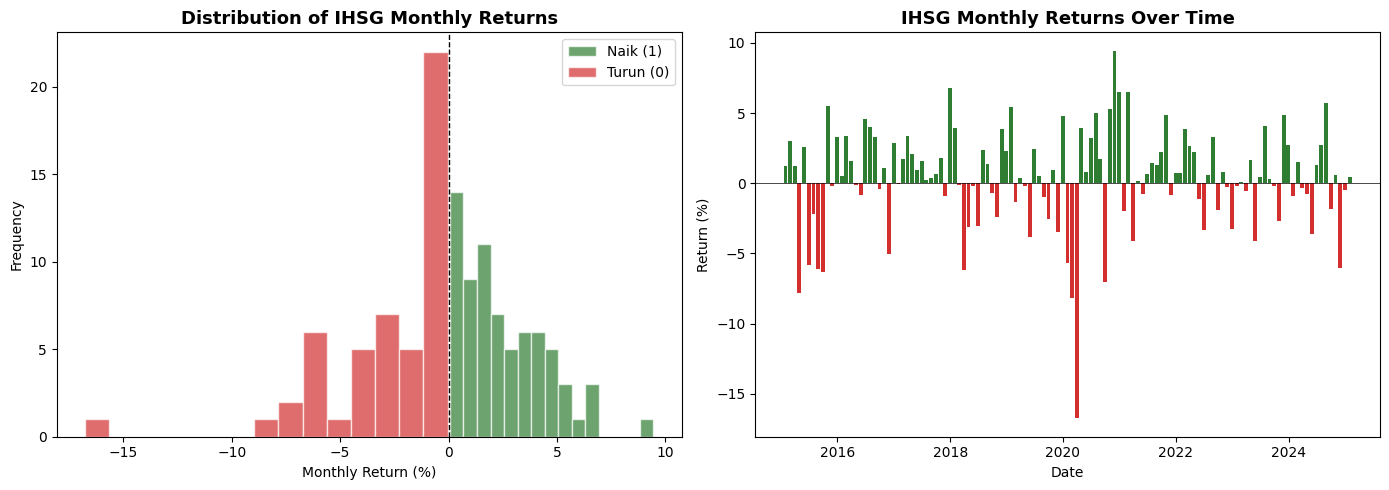

✅ Saved: classification_eda.png


In [7]:
print("\n" + "=" * 70)
print("CELL 3: DESCRIPTIVE STATISTICS & EDA")
print("=" * 70)

# Descriptive stats
print("\n--- Descriptive Statistics ---")
print(df_model[['IHSG', 'IHSG_Return', 'M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']].describe().round(4).to_string())

# Return by direction
print("\n--- IHSG Return by Direction ---")
for direction in [1, 0]:
    subset = df_model[df_model['IHSG_Direction'] == direction]['IHSG_Return']
    label = "Naik" if direction == 1 else "Turun"
    print(f"  {label}: n={len(subset)}, mean={subset.mean():.2f}%, std={subset.std():.2f}%, "
          f"min={subset.min():.2f}%, max={subset.max():.2f}%")

# Correlation
print("\n--- Correlation with IHSG Direction ---")
for col in ['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio']:
    corr = df_model[col].corr(df_model['IHSG_Direction'])
    print(f"  {col:15s}: {corr:+.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model[df_model['IHSG_Direction']==1]['IHSG_Return'], bins=15,
             alpha=0.7, color=COLORS['up'], label='Naik (1)', edgecolor='white')
axes[0].hist(df_model[df_model['IHSG_Direction']==0]['IHSG_Return'], bins=15,
             alpha=0.7, color=COLORS['down'], label='Turun (0)', edgecolor='white')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Distribution of IHSG Monthly Returns', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

colors_ts = [COLORS['up'] if d == 1 else COLORS['down'] for d in df_model['IHSG_Direction']]
axes[1].bar(df_model['Date'], df_model['IHSG_Return'], color=colors_ts, width=25)
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title('IHSG Monthly Returns Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.savefig('classification_eda.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_eda.png")


In [8]:
print("\n" + "=" * 70)
print("CELL 4: DARTS TIMESERIES & TRAIN/TEST SPLIT")
print("=" * 70)

# Target: IHSG Direction (0.0 / 1.0)
target_series = TimeSeries.from_dataframe(
    df_model, time_col='Date', value_cols='IHSG_Direction', freq='ME'
)

# Covariates
covar_series = TimeSeries.from_dataframe(
    df_model, time_col='Date', 
    value_cols=['M2_YoY', 'USDIDR', 'BI_Rate', 'NPL_Ratio'], freq='ME'
)

# Train/Test Split 80:20
split_point = int(len(target_series) * 0.8)
target_train = target_series[:split_point]
target_test = target_series[split_point:]

# Scale covariates only (target is binary)
scaler_covar = Scaler(MinMaxScaler(feature_range=(-1, 1)))
covar_train_scaled = scaler_covar.fit_transform(covar_series[:split_point])
covar_test_scaled = scaler_covar.transform(covar_series[split_point:])
covar_full_scaled = covar_train_scaled.append(covar_test_scaled)

print(f"Train: {target_train.start_time()} → {target_train.end_time()} ({len(target_train)} obs)")
print(f"Test:  {target_test.start_time()} → {target_test.end_time()} ({len(target_test)} obs)")

train_vals = target_train.values().flatten()
test_vals = target_test.values().flatten()
print(f"\nTrain distribution: Naik={int(train_vals.sum())} ({train_vals.mean()*100:.1f}%), "
      f"Turun={int(len(train_vals)-train_vals.sum())} ({(1-train_vals.mean())*100:.1f}%)")
print(f"Test distribution:  Naik={int(test_vals.sum())} ({test_vals.mean()*100:.1f}%), "
      f"Turun={int(len(test_vals)-test_vals.sum())} ({(1-test_vals.mean())*100:.1f}%)")
print(f"\n✓ Covariates scaled (fit on train only, no leakage)")


CELL 4: DARTS TIMESERIES & TRAIN/TEST SPLIT
Train: 2015-01-31 00:00:00 → 2022-12-31 00:00:00 (96 obs)
Test:  2023-01-31 00:00:00 → 2025-01-31 00:00:00 (25 obs)

Train distribution: Naik=58 (60.4%), Turun=38 (39.6%)
Test distribution:  Naik=13 (52.0%), Turun=12 (48.0%)

✓ Covariates scaled (fit on train only, no leakage)


In [ ]:
# =====================================================
# CELL 5: RANDOM FOREST CLASSIFIER — DARTS GRIDSEARCH
# =====================================================
print("\n" + "=" * 70)
print("CELL 5: RANDOM FOREST CLASSIFIER — GRIDSEARCH")
print("=" * 70)

# Define sklearn RF configurations
rf_instances = [
    RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', 
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=100, max_depth=5, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=100, max_depth=7, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=100, max_depth=None, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=200, max_depth=3, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=200, max_depth=5, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=200, max_depth=7, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=200, max_depth=None, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=200, max_depth=5, max_features='log2',
                           min_samples_split=5, min_samples_leaf=4, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=200, max_depth=7, max_features='log2',
                           min_samples_split=5, min_samples_leaf=4, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=300, max_depth=5, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=2, random_state=42, n_jobs=-1),
    RandomForestClassifier(n_estimators=300, max_depth=7, max_features='sqrt',
                           min_samples_split=2, min_samples_leaf=4, random_state=42, n_jobs=-1),
]

param_grid_rf = {
    'lags': [1, 3, 6],
    'lags_past_covariates': [1, 3, 6],
    'output_chunk_length': [1],
    'model': rf_instances,
}

total_combos = 3 * 3 * 1 * len(rf_instances)
print(f"Total parameter combinations: {total_combos}")
print(f"RF model variants: {len(rf_instances)}")
print(f"Lags options: [1, 3, 6]")
print(f"Lags covariates options: [1, 3, 6]")
print(f"\nRunning Darts native gridsearch (metric=accuracy)...")

best_rf_model, best_rf_params, best_rf_score = SKLearnClassifierModel.gridsearch(
    parameters=param_grid_rf,
    series=target_train,
    past_covariates=covar_full_scaled,
    val_series=target_test,
    forecast_horizon=1,
    metric=metrics.accuracy,
    verbose=True,
    n_jobs=1,  # n_jobs=1 to avoid parallel issues with sklearn models
)

print(f"\n✅ RF GridSearch Complete")
print(f"Best Accuracy (GridSearch): {best_rf_score:.4f}")
print(f"\nBest Parameters:")
for k, v in best_rf_params.items():
    if k == 'model':
        # Print sklearn model params
        print(f"  model: RandomForestClassifier")
        print(f"    n_estimators: {v.n_estimators}")
        print(f"    max_depth: {v.max_depth}")
        print(f"    max_features: {v.max_features}")
        print(f"    min_samples_split: {v.min_samples_split}")
        print(f"    min_samples_leaf: {v.min_samples_leaf}")
    else:
        print(f"  {k}: {v}")

# Save best params (serializable version)
rf_best_sklearn = best_rf_params.get('model', rf_instances[0])
rf_params_save = {
    'lags': best_rf_params.get('lags'),
    'lags_past_covariates': best_rf_params.get('lags_past_covariates'),
    'output_chunk_length': best_rf_params.get('output_chunk_length', 1),
    'n_estimators': rf_best_sklearn.n_estimators,
    'max_depth': str(rf_best_sklearn.max_depth),
    'max_features': rf_best_sklearn.max_features,
    'min_samples_split': rf_best_sklearn.min_samples_split,
    'min_samples_leaf': rf_best_sklearn.min_samples_leaf,
}
with open('rf_classifier_best_params.json', 'w') as f:
    json.dump(rf_params_save, f, indent=2)
print("✓ Saved: rf_classifier_best_params.json")



CELL 5: RANDOM FOREST CLASSIFIER — GRIDSEARCH
Total parameter combinations: 108
RF model variants: 12
Lags options: [1, 3, 6]
Lags covariates options: [1, 3, 6]

Running Darts native gridsearch (metric=accuracy)...


gridsearch:   0%|          | 0/108 [00:00<?, ?it/s]

This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
This model will treat target `series` lagged values as numeric input features (and not categorical).
`predict()` was called with `n > output_chunk_length`: us


✅ RF GridSearch Complete
Best Accuracy (GridSearch): 0.3600

Best Parameters:
  lags: 3
  lags_past_covariates: 3
  output_chunk_length: 1
  model: RandomForestClassifier
    n_estimators: 100
    max_depth: 7
    max_features: sqrt
    min_samples_split: 2
    min_samples_leaf: 2
✓ Saved: rf_classifier_best_params.json
